# Reinforcement learning tutorial

Prepared by Mihály Bányai, 2026. mihaly.s.banyai@gmail.com, https://visionlab-ceu.org/people/mihaly-banyai/ 

The first block, after the imports, implements a plotting function that we will use to see what our algorithms learned in the example problems. It's been largely written by an LLM, and it does not contain any scientific of algorithmic solutions, but feel free to look into it or adapt it to your purposes.

In [140]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import random

def plot_gridworld(
    grid,
    init_state,
    q_function=None,
    value_function=None,
    cmap_cells="viridis",
    cmap_q="coolwarm",
    arrow_scale=0.25,
    wall_color="lightgray",
):
    """
    Plot a gridworld with walls, rewarded cells, and an initial state. Written mostly by ChatGPT.

    grid : array-like, shape (n, m)
        0 = normal state
        1 = wall
        3 = rewarded cell (red border)
    value_function : array-like, shape (n*m,) or (n*m, 1)
        State value function (row-major).
    q_function : array-like, shape (n*m, 4)
        Q-values per state in order: [left, up, right, down].
    init_state : int
        Initial state index (row-major), highlighted in yellow.
    """
    grid = np.asarray(grid)
    n, m = grid.shape

    noplot_q = False
    if q_function is None:
        noplot_q = True
        q_function = np.zeros((n * m, 4))
    Q = np.asarray(q_function)
    if value_function is None:
        value_function = Q.max(axis=1)
    V = np.asarray(value_function).reshape(-1)
   

    if V.size != n * m:
        raise ValueError("Value function must have size n*m")
    if Q.shape != (n * m, 4):
        raise ValueError("Q function must have shape (n*m, 4)")
    if not (0 <= init_state < n * m):
        raise ValueError("init_state out of bounds")

    # Mask walls for value coloring
    V_grid = V.reshape(n, m)
    V_masked = np.ma.masked_where(grid == 1, V_grid)

    fig, ax = plt.subplots()
    im = ax.imshow(V_masked, cmap=cmap_cells, origin="upper")

    # Grid lines
    ax.set_xticks(np.arange(-0.5, m, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax.grid(which="minor", linewidth=1)
    ax.tick_params(left=False, bottom=False,
                   labelleft=False, labelbottom=False)

    # Draw walls
    for i in range(n):
        for j in range(m):
            if grid[i, j] == 1:
                ax.add_patch(
                    Rectangle((j - 0.5, i - 0.5), 1, 1,
                              facecolor=wall_color, edgecolor="black")
                )

    # Normalize Q-values
    q_min, q_max = Q.min(), Q.max()
    norm = plt.Normalize(q_min, q_max)
    q_cmap = plt.get_cmap(cmap_q)

    # Action directions: left, up, right, down
    directions = {
        0: (-arrow_scale, 0),   # left
        1: (0, -arrow_scale),   # up
        2: (arrow_scale, 0),    # right
        3: (0, arrow_scale),    # down
    }

    for s in range(n * m):
        i, j = divmod(s, m)

        if grid[i, j] == 1:
            continue  # wall

        cx, cy = j, i

        if not noplot_q:
            # Draw Q arrows
            for a in range(4):
                dx, dy = directions[a]
                color = q_cmap(norm(Q[s, a]))

                ax.arrow(
                    cx, cy,
                    dx, dy,
                    width=0.02,
                    head_width=0.08,
                    head_length=0.08,
                    length_includes_head=True,
                    color=color,
                    alpha=0.9,
                )

        # Rewarded cell border
        if grid[i, j] == 3:
            ax.add_patch(
                Rectangle((j - 0.5, i - 0.5), 1, 1,
                          fill=False, edgecolor="red", linewidth=3)
            )

    # Initial state border (draw last so it’s visible)
    init_i, init_j = divmod(init_state, m)
    if grid[init_i, init_j] != 1:
        ax.add_patch(
            Rectangle((init_j - 0.5, init_i - 0.5), 1, 1,
                      fill=False, edgecolor="yellow", linewidth=3)
        )

    # Colorbars
    plt.colorbar(im, ax=ax, label="V(s)")
    if not noplot_q:
        sm = plt.cm.ScalarMappable(norm=norm, cmap=q_cmap)
        sm.set_array([])
        plt.colorbar(sm, ax=ax, label="Q(s,a)")

    plt.show()

## Temporal difference learning

The basic equation to iteratively update a value function in a passive environment, solving the credit assigmnent problem without learning model of state transitions:

$V(s_t) \leftarrow V(s_t) + \alpha \left(R_{t+1} + \gamma V(s_{t+1}) - V(s_t) \right)$

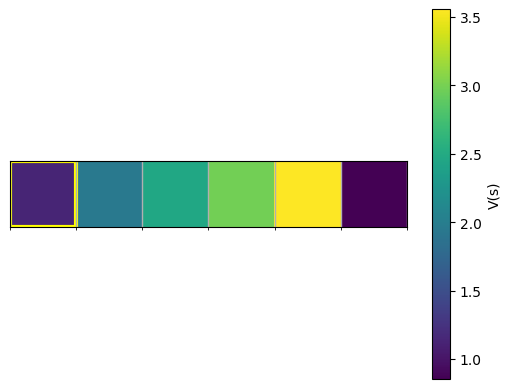

In [188]:
def conveyor_belt_state_space(n_states, cue_prob):
    assert cue_prob <= 1. and cue_prob >= 0.
    map_cb = [[0] * n_states]
    map_cb[0][-1] = cue_prob
    T = np.zeros((n_states, n_states))
    T[0, 1] = cue_prob
    T[0, 0] = 1. - cue_prob
    for s in range(1, n_states-1):
        T[s, s+1] = 1
    T[-1, 0] = 1
    R = np.zeros((n_states))
    R[-1] = 3
    return T, R, map_cb

def temporal_difference_learning(T, R, n_step, gamma, alpha):
    n_states = R.shape[0]
    states = list(range(n_states))
    V = np.zeros(n_states)
    td_errors = np.zeros((n_step, 2))
    act_state = 0
    for i in range(n_step):
        next_state = np.random.choice(states, size=1, p=T[act_state, :].flatten()).item()
        reward = R[next_state]

        TD = reward + gamma * V[next_state] - V[act_state]
        td_errors[i, 0] = act_state
        td_errors[i, 1] = TD 
        #V[act_state] = (1-alpha) * V[act_state] + alpha * TD
        V[act_state] += alpha * TD

        act_state = next_state
    return V, td_errors

T_conv, R_conv, map_conv = conveyor_belt_state_space(6, cue_prob=0.3)
#print(T_conv, R_conv, map_conv)
V, td_errors = temporal_difference_learning(T_conv, R_conv, 500, 0.9, 0.1)
#print(V)
plot_gridworld(map_conv, 0, value_function=V)

Relocation of TD errors

Text(0, 0.5, 'TD error')

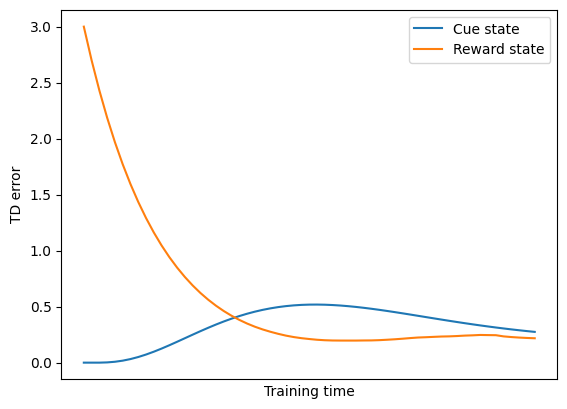

In [191]:
cue_state_idx = td_errors[:, 0] == 1
plt.plot(td_errors[cue_state_idx, 1], label="Cue state")
reward_state_idx = td_errors[:, 0] == T_conv.shape[0] - 2
plt.plot(td_errors[reward_state_idx, 1], label="Reward state")
plt.legend()
plt.xlabel("Training time")
plt.xticks([])
plt.ylabel("TD error")

In [135]:
def transition_probs_from_map(map, start_state):
    n_rows = len(map)
    n_cols = len(map[0])
    n_states = n_rows * n_cols
    n_actions = 4 # left, up, right, down
    action_neighbors = [(0, -1), (-1, 0), (0, 1), (1, 0)]
    T = np.zeros((n_states, n_states, n_actions))
    R = np.zeros((n_states))
    for row_idx, row in enumerate(map):
        for cell_idx, cell in enumerate(row):
            state_idx = row_idx * n_cols + cell_idx
            if cell > 1:
                R[state_idx] = cell
            for action in range(n_actions):
                if cell > 1:
                    T[state_idx, start_state, action] = 1.
                else:
                    target_row = row_idx + action_neighbors[action][0]
                    target_column = cell_idx + action_neighbors[action][1]
                    if target_row < 0 or target_row >= n_rows or target_column < 0 or target_column >= n_cols:
                        T[state_idx, state_idx, action] = 1.
                    else:
                        target_resistance = map[target_row][target_column] if map[target_row][target_column] <= 1 else 0
                        T[state_idx, state_idx, action] = target_resistance
                        target_state = target_row * n_cols + target_column
                        T[state_idx, target_state, action] = 1. - target_resistance
    return T, R


In [195]:
def evaluate_Q(T, R, init_state, Q, n_step, action_penalty=None):
    n_states = R.shape[0]
    n_actions = T.shape[2]
    collected_reward = 0
    act_state = init_state
    states = list(range(n_states))
    actions = list(range(n_actions))
    for s in range(n_step):
        reward = R[act_state]
        reward += 0 if action_penalty is None else action_penalty
        collected_reward += reward
        best_actions = np.argwhere(Q[act_state, :] == np.amax(Q[act_state, :])).flatten().tolist()
        action = random.choice(best_actions)
        act_state = np.random.choice(states, size=1, p=T[act_state, :, action].flatten()).item()
    return collected_reward



def Q_learning(T, R, gamma, max_iter, alpha, epsilon, init_state, Q_init=None, action_penalty=None, eval_interval=None, eval_step=1000):
    n_states = R.shape[0]
    n_actions = T.shape[2]
    states = list(range(n_states))
    actions = list(range(n_actions))
    Q = np.zeros((n_states, n_actions))
    if not Q_init is None:
        Q = np.copy(Q_init)
    value_sums = [0]
    eval_perfs = [evaluate_Q(T, R, init_state, Q, eval_step, action_penalty=action_penalty) if eval_interval is not None else 0]
    act_state = init_state
    for i in range(max_iter):
        if random.uniform(0, 1) < epsilon:
            action = random.choice(actions)
        else:
            best_actions = np.argwhere(Q[act_state, :] == np.amax(Q[act_state, :])).flatten().tolist()
            action = random.choice(best_actions)

        #print(T[act_state, :, action].flatten())
        next_state = np.random.choice(states, size=1, p=T[act_state, :, action].flatten()).item()
        reward = R[next_state]
        reward += 0 if action_penalty is None else action_penalty
        TD = reward + gamma * Q[next_state, :].max()
        Q[act_state, action] = (1 - alpha) * Q[act_state, action] + alpha * TD

        if eval_interval is not None and i % eval_interval == 0:
            eval_perfs.append(evaluate_Q(T, R, init_state, Q, eval_step, action_penalty=action_penalty))

        act_state = next_state
        value_sums.append(Q.sum() / n_states)
    
    if eval_interval is not None:
        plt.plot(np.array(range(len(eval_perfs))) * eval_interval , eval_perfs)
        plt.xlabel("Training step")
        plt.ylabel("Performance on %d steps" % eval_step)
        
    return value_sums, Q, eval_perfs

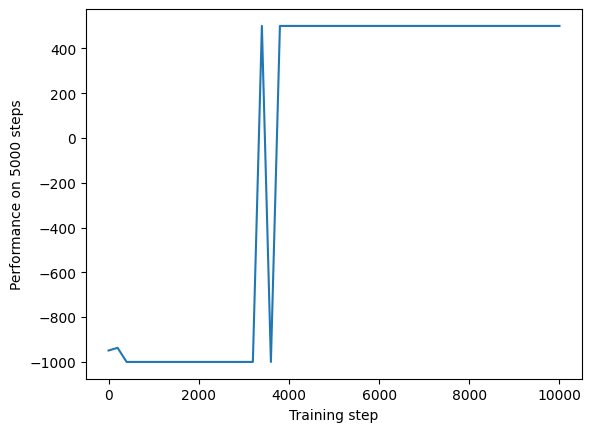

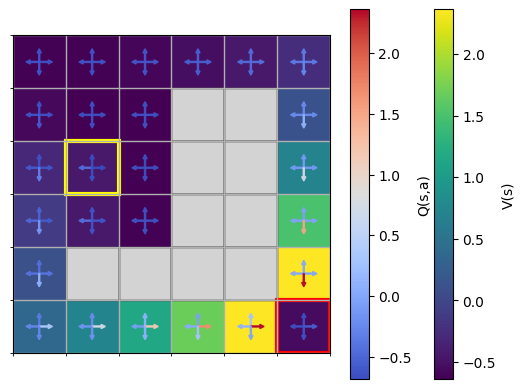

In [196]:
large_map = [
    [0, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 1, 0],
    [0, 0, 0, 1, 1, 0],
    [0, 0, 0, 1, 1, 0],
    [0, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 3]
]

large_init_state = 13
T_map, R_map = transition_probs_from_map(large_map, start_state=large_init_state)
eval_interval = 200
vs_q_po, Q_po, eval_perfs = Q_learning(T_map, R_map, 0.8, 10000, 0.1, 0.01, large_init_state, action_penalty=-0.2, eval_interval=200, eval_step=5000)

plot_gridworld(large_map, large_init_state, q_function=Q_po)